# 📊 Statistical Test: Wilcoxon / Paired t-test

## 논문 Table 1, 2 에 대한 통계 검정

### Table 1 — Novel Activity Detection
- **비교**: MAND(Ours) vs 각 [CL method + Scoring function] 조합
- **Metrics**: AUC↑, FPR95↓
- **Settings**: Short(Inc:8), Mid(Inc:4), Long(Inc:2)
- **Symbol**: ▼ = 통계적으로 Ours보다 나쁨, △ = Ours보다 좋음

### Table 2 — Known Classification
- **비교**: MAND(Ours) vs 각 CL method
- **Metrics**: ACC↑, FGT↓
- **Settings**: Short(Inc:8), Mid(Inc:4), Long(Inc:2)

### 검정 방법
1. **정규성 검정** (Shapiro-Wilk, n=5 seeds)
2. 정규분포(p≥0.05) → **Paired t-test** (양측)
3. 비정규(p<0.05) → **Wilcoxon signed-rank test** (양측)
4. 유의수준 α=0.05

## Cell 1. 라이브러리 로드

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import shapiro, ttest_rel, wilcoxon
import wandb

warnings.filterwarnings('ignore')
os.makedirs('results', exist_ok=True)
os.makedirs('results/figures', exist_ok=True)

print('✅ 라이브러리 로드 완료')

✅ 라이브러리 로드 완료


## Cell 2. WandB Sweep ID 설정

각 모델의 **eval** sweep ID를 입력하세요.
- 각 sweep은 5 seeds × 3 increments = 15 runs을 포함해야 합니다.
- WandB project: `mmea-owcl` (또는 실제 project name)

In [2]:
# ============================================================
# WandB 설정
# ============================================================
WANDB_ENTITY  = 'mmea-owcl'   # WandB 팀/엔티티 이름
WANDB_PROJECT = 'Experimental Results on the MMEA-OWCL (Evaluation CL & OOD)'  # 프로젝트 이름

# ============================================================
# Sweep ID 입력 — 각 모델의 eval sweep ID를 여기에 입력
# ============================================================
# Table 1 & 2 에 사용되는 모든 모델의 sweep ID
# 형식: { '논문에서의 이름': 'sweep_id' }

SWEEP_IDS = {
    # ── 우리 방법 ─────────────────────────────────────────────
    'MAND':     '8o67o3at',   # MAND(Ours) eval sweep

    # ── Baselines ─────────────────────────────────────────────
    'iCaRL':    'wc0pzspe',
    'ER':       '6zdeyulp',
    'DER++':    'nk3a2jc7',
    'Foster':   'olzsmzg2',
    'CMR-MFN':  'tm5ko8mi',
    'MONET':    'wab6rt1z',
}

# ============================================================
# 실험 설정
# ============================================================
SEEDS      = [1993, 1994, 1995, 1996, 1997]
INCREMENTS = [8, 4, 2]                          # Short, Mid, Long
INC_NAMES  = {8: 'Short(Inc:8)', 4: 'Mid(Inc:4)', 2: 'Long(Inc:2)'}
ALPHA      = 0.05                               # 유의수준

# Table 1에서 사용하는 Scoring 방법들
# WandB run의 config 'ood_methods' 또는 summary key 이름과 일치해야 함
SCORING_METHODS = ['MSP', 'MaxLogit', 'Entropy', 'Energy']  # 필요시 수정

# 우리 방법의 Scoring 이름 (WandB summary key 확인 후 수정)
OURS_SCORING = 'MAND'

print('✅ 설정 완료')
print(f'  Entity: {WANDB_ENTITY}')
print(f'  Project: {WANDB_PROJECT}')
print(f'  Seeds: {SEEDS}')
print(f'  Increments: {INCREMENTS}')

✅ 설정 완료
  Entity: mmea-owcl
  Project: Experimental Results on the MMEA-OWCL (Evaluation CL & OOD)
  Seeds: [1993, 1994, 1995, 1996, 1997]
  Increments: [8, 4, 2]


## Cell 3. WandB에서 데이터 로드

In [3]:
# ============================================================
# WandB API로 sweep runs 로드 (+ Forgetting 계산)
# ============================================================
import re

api = wandb.Api(timeout=60)

# ── Forgetting 관련 헬퍼 함수 (notebook 4 방식) ──────────────

def _get_task_acc_cols(hist_or_row):
    """Task/[XX-YY]_acc 패턴 컬럼명 추출"""
    keys = hist_or_row.columns if hasattr(hist_or_row, 'columns') else hist_or_row.keys()
    acc = [k for k in keys
           if isinstance(k, str) and k.startswith('Task/[') and k.endswith(']_acc') and 'NME' not in k]
    return sorted(acc, key=lambda x: int(re.search(r'[(\[]?(\d+)-', str(x)).group(1))
                  if re.search(r'[(\[]?(\d+)-', str(x)) else 0)

def _get_history_data(run):
    """run.history() 로드 → (hist_df, acc_cols) 반환"""
    try:
        hist = run.history(samples=5000)
        if hist is not None and len(hist) >= 1:
            acc_cols = _get_task_acc_cols(hist)
            if acc_cols:
                return hist, acc_cols
    except Exception:
        pass
    try:
        rows = list(run.scan_history())
        if rows:
            acc_cols = _get_task_acc_cols(rows[0])
            if acc_cols:
                return pd.DataFrame(rows), acc_cols
    except Exception:
        pass
    return None, []

def _compute_forgetting(hist, acc_cols):
    """Mammoth-style average forgetting (Chaudhry et al. / mammoth utils):
    평균_i [ max_τ( task i 학습 중 τ 시점 이후 기록된 i번째 그룹 정확도 ) - 최종 정확도_i ],
    i는 마지막 태스크를 제외한 학습된 그룹들(노트북 1.performance_comp_table_tiny forgetting()과 동일).
    """
    if hist is None or len(acc_cols) < 2:
        return np.nan
    n_tasks = len(acc_cols)
    if 'Task/Task_ID' in hist.columns:
        h = hist.dropna(subset=['Task/Task_ID']).copy()
        if h.empty:
            return np.nan
        # 동일 Task_ID가 여러 행이면 tail(n_tasks)만 쓰면 잘못된 스텝만 남을 수 있음 → 태스크당 마지막 로그 사용
        h = h.sort_values('Task/Task_ID').groupby(
            'Task/Task_ID', sort=False, as_index=False
        ).last()
        h = h.sort_values('Task/Task_ID')
    else:
        h = hist.dropna(subset=[acc_cols[0]], how='all').tail(n_tasks)
    if len(h) < 2 or len(h) < n_tasks:
        return np.nan
    h = h.iloc[:n_tasks]
    results = []
    for t, (_, row) in enumerate(h.iterrows()):
        vals = [
            float(row[c]) if pd.notna(row.get(c)) else 0.0
            for c in acc_cols[: t + 1]
        ]
        results.append(vals + [0.0] * (n_tasks - len(vals)))
    np_res = np.array(results)
    max_acc = np.max(np_res, axis=0)
    return float(
        np.mean([max_acc[i] - results[-1][i] for i in range(n_tasks - 1)])
    )

# ── Sweep 로드 함수 ───────────────────────────────────────────

def load_sweep_runs(sweep_id, entity=WANDB_ENTITY, project=WANDB_PROJECT):
    """
    sweep ID로 모든 run을 로드하여 DataFrame 반환.
    - run.summary: AUC, FPR95, ACC 등
    - run.history: Task/[XX-YY]_acc → Forgetting 계산 후 'Task/forgetting' 컬럼 추가
    """
    sweep = api.sweep(f'{entity}/{project}/{sweep_id}')
    rows = []
    for run in sweep.runs:
        row = {
            'run_id':    run.id,
            'run_name':  run.name,
            'state':     run.state,
            'seed':      run.config.get('seed'),
            'increment': run.config.get('increment'),
            'model_name':run.config.get('model_name'),
            'fusion_type':run.config.get('fusion_type'),
        }
        # summary 전체 병합 (AUC, FPR95, Task/avg_acc 등)
        row.update(dict(run.summary))

        # Forgetting: summary에 이미 있으면 사용, 없으면 history에서 계산
        if pd.isna(row.get('Task/forgetting', float('nan'))):
            hist, acc_cols = _get_history_data(run)
            row['Task/forgetting'] = _compute_forgetting(hist, acc_cols)

        rows.append(row)
    return pd.DataFrame(rows)

# ── 전체 sweep 로드 실행 ──────────────────────────────────────

all_dfs = {}
for method_name, sweep_id in SWEEP_IDS.items():
    print(f'  📥 {method_name} ({sweep_id}) 로드 중...')
    try:
        df = load_sweep_runs(sweep_id)
        all_dfs[method_name] = df
        fgt_ok = df['Task/forgetting'].notna().sum()
        print(f'     ✅ {len(df)} runs 로드 완료  (Forgetting 계산됨: {fgt_ok}/{len(df)} runs)')
    except Exception as e:
        print(f'     ❌ 로드 실패: {e}')

print(f'\n✅ 총 {len(all_dfs)}개 모델 로드 완료: {list(all_dfs.keys())}')
print('  ⚠️  history 로드로 인해 시간이 걸릴 수 있습니다 (sweep당 1-3분)')

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /workspace/.netrc.


  📥 MAND (8o67o3at) 로드 중...
     ✅ 15 runs 로드 완료  (Forgetting 계산됨: 15/15 runs)
  📥 iCaRL (wc0pzspe) 로드 중...
     ✅ 15 runs 로드 완료  (Forgetting 계산됨: 15/15 runs)
  📥 ER (6zdeyulp) 로드 중...
     ✅ 15 runs 로드 완료  (Forgetting 계산됨: 15/15 runs)
  📥 DER++ (nk3a2jc7) 로드 중...
     ✅ 15 runs 로드 완료  (Forgetting 계산됨: 15/15 runs)
  📥 Foster (olzsmzg2) 로드 중...
     ✅ 15 runs 로드 완료  (Forgetting 계산됨: 15/15 runs)
  📥 CMR-MFN (tm5ko8mi) 로드 중...
     ✅ 15 runs 로드 완료  (Forgetting 계산됨: 15/15 runs)
  📥 MONET (wab6rt1z) 로드 중...
     ✅ 15 runs 로드 완료  (Forgetting 계산됨: 15/15 runs)

✅ 총 7개 모델 로드 완료: ['MAND', 'iCaRL', 'ER', 'DER++', 'Foster', 'CMR-MFN', 'MONET']
  ⚠️  history 로드로 인해 시간이 걸릴 수 있습니다 (sweep당 1-3분)


In [4]:
# ============================================================
# 로드된 데이터 컬럼 확인 — MAND, iCaRL, ER 각각 출력
# SCORING_KEY_MAP 검증용: iCaRL/ER에 MSP/Entropy/Energy 컬럼 있는지 확인
# ============================================================
for check_name in ['MAND', 'iCaRL', 'ER']:
    df = all_dfs.get(check_name)
    if df is None:
        print(f'⚠️  {check_name}: 데이터 없음')
        continue

    print(f'\n📋 [{check_name}] OOD 관련 컬럼:')
    ood_cols = sorted([c for c in df.columns
                       if any(k in c.lower() for k in ['auroc','fpr95','auc','ood'])])
    for c in ood_cols:
        print(f'  {c}')

    print(f'\n📋 [{check_name}] ACC / Forgetting 관련 컬럼:')
    acc_cols = sorted([c for c in df.columns
                       if any(k in c.lower() for k in ['avg_acc','forgetting','fgt'])])
    for c in acc_cols:
        print(f'  {c}')
    print()


📋 [MAND] OOD 관련 컬럼:
  Average_OOD/MaxLogit_Baseline_aupr_id
  Average_OOD/MaxLogit_Baseline_aupr_ood
  Average_OOD/MaxLogit_Baseline_auroc
  Average_OOD/MaxLogit_Baseline_fpr95
  Average_OOD/MaxLogit_Baseline_id_samples
  Average_OOD/MaxLogit_Baseline_ood_samples
  Average_OOD/MaxLogit_Hybrid_UniformAverage_aupr_id
  Average_OOD/MaxLogit_Hybrid_UniformAverage_aupr_ood
  Average_OOD/MaxLogit_Hybrid_UniformAverage_auroc
  Average_OOD/MaxLogit_Hybrid_UniformAverage_fpr95
  Average_OOD/MaxLogit_Hybrid_UniformAverage_id_samples
  Average_OOD/MaxLogit_Hybrid_UniformAverage_ood_samples
  Average_OOD/MaxLogit_Hybrid_UniformSum_aupr_id
  Average_OOD/MaxLogit_Hybrid_UniformSum_aupr_ood
  Average_OOD/MaxLogit_Hybrid_UniformSum_auroc
  Average_OOD/MaxLogit_Hybrid_UniformSum_fpr95
  Average_OOD/MaxLogit_Hybrid_UniformSum_id_samples
  Average_OOD/MaxLogit_Hybrid_UniformSum_ood_samples
  Final/MaxLogit_Baseline_avg_aupr_ood
  Final/MaxLogit_Baseline_avg_auroc
  Final/MaxLogit_Hybrid_UniformAverage_a

In [5]:
# ============================================================
# 컬럼 이름 매핑 — 실제 WandB 컬럼 확인 후 설정
# ============================================================

# ── Table 1: AUC / FPR95 ─────────────────────────────────────
# 베이스라인 컬럼 패턴: Average_OOD/{method}_auroc / _fpr95
# 예: Average_OOD/MSP_Baseline_auroc, Average_OOD/Energy_Baseline_fpr95
COL_AUC_TEMPLATE   = 'Average_OOD/{method}_auroc'
COL_FPR95_TEMPLATE = 'Average_OOD/{method}_fpr95'

# 베이스라인 scoring key 이름 (Average_OOD/ 뒤에 오는 이름)
# ⚠️ iCaRL/ER sweep 컬럼 확인 후 수정 필요
SCORING_KEY_MAP = {
    'MSP':      'MSP_Baseline',
    'MaxLogit': 'MaxLogit_Baseline',
    'Entropy':  'Entropy_Baseline',
    'Energy':   'Energy_Baseline',
}

# ── MAND(Ours) 최종 성능 = MaxLogit Hybrid UniformAverage ─────
# 확인된 컬럼명: Average_OOD/MaxLogit_Hybrid_UniformAverage_auroc / _fpr95
OURS_SCORING_KEY = 'MaxLogit_Hybrid_UniformAverage'
OURS_AUC_KEY     = f'Average_OOD/{OURS_SCORING_KEY}_auroc'    # ✅ 확인됨
OURS_FPR95_KEY   = f'Average_OOD/{OURS_SCORING_KEY}_fpr95'   # ✅ 확인됨

# ── Table 2: ACC / FGT ───────────────────────────────────────
COL_ACC = 'Task/avg_acc'       # ✅ 확인됨
COL_FGT = 'Task/forgetting'   # ✅ 확인됨 (summary에 존재)

print('✅ 컬럼 매핑 설정 완료')
print(f'  MAND AUC   : {OURS_AUC_KEY}')
print(f'  MAND FPR95 : {OURS_FPR95_KEY}')
print(f'  ACC        : {COL_ACC}')
print(f'  FGT        : {COL_FGT}')
print()
print('  베이스라인 예시:')
for k, v in SCORING_KEY_MAP.items():
    print(f'    {k:10s} → {COL_AUC_TEMPLATE.format(method=v)}')
print('  ⚠️ iCaRL/ER sweep 컬럼명 확인 후 SCORING_KEY_MAP 수정 필요')

✅ 컬럼 매핑 설정 완료
  MAND AUC   : Average_OOD/MaxLogit_Hybrid_UniformAverage_auroc
  MAND FPR95 : Average_OOD/MaxLogit_Hybrid_UniformAverage_fpr95
  ACC        : Task/avg_acc
  FGT        : Task/forgetting

  베이스라인 예시:
    MSP        → Average_OOD/MSP_Baseline_auroc
    MaxLogit   → Average_OOD/MaxLogit_Baseline_auroc
    Entropy    → Average_OOD/Entropy_Baseline_auroc
    Energy     → Average_OOD/Energy_Baseline_auroc
  ⚠️ iCaRL/ER sweep 컬럼명 확인 후 SCORING_KEY_MAP 수정 필요


## Cell 4. Per-seed 값 추출 함수

In [6]:
# ============================================================
# seed × increment 기준으로 값 추출
# ============================================================

def get_values(df, col, increment, seeds=SEEDS):
    """
    특정 컬럼의 per-seed 값을 np.array로 반환.
    df에 'increment', 'seed' 컬럼이 있다고 가정.
    """
    if col not in df.columns:
        return np.full(len(seeds), np.nan)

    subset = df[df['increment'] == increment] if 'increment' in df.columns else df
    values = []
    for seed in seeds:
        row = subset[subset['seed'] == seed] if 'seed' in subset.columns else subset
        # 동일 seed가 여러 개면 첫 번째 사용
        val = row[col].iloc[0] if len(row) > 0 else np.nan
        values.append(float(val) if pd.notna(val) else np.nan)
    return np.array(values)


def get_auc_values(method_name, scoring_key, increment):
    """Table 1용: AUC per-seed 값"""
    df  = all_dfs.get(method_name)
    if df is None: return np.full(len(SEEDS), np.nan)
    col = COL_AUC_TEMPLATE.format(method=scoring_key)
    return get_values(df, col, increment)


def get_fpr95_values(method_name, scoring_key, increment):
    """Table 1용: FPR95 per-seed 값"""
    df  = all_dfs.get(method_name)
    if df is None: return np.full(len(SEEDS), np.nan)
    col = COL_FPR95_TEMPLATE.format(method=scoring_key)
    return get_values(df, col, increment)


def get_ours_auc(increment):
    """MAND(Ours) AUC per-seed 값"""
    df = all_dfs.get('MAND')
    if df is None: return np.full(len(SEEDS), np.nan)
    return get_values(df, OURS_AUC_KEY, increment)


def get_ours_fpr95(increment):
    """MAND(Ours) FPR95 per-seed 값"""
    df = all_dfs.get('MAND')
    if df is None: return np.full(len(SEEDS), np.nan)
    return get_values(df, OURS_FPR95_KEY, increment)


def get_acc_values(method_name, increment):
    """Table 2용: ACC per-seed 값"""
    df = all_dfs.get(method_name)
    if df is None: return np.full(len(SEEDS), np.nan)
    return get_values(df, COL_ACC, increment)


def get_fgt_values(method_name, increment):
    """Table 2용: FGT per-seed 값"""
    df = all_dfs.get(method_name)
    if df is None: return np.full(len(SEEDS), np.nan)
    return get_values(df, COL_FGT, increment)


print('✅ 데이터 추출 함수 정의 완료')

✅ 데이터 추출 함수 정의 완료


## Cell 5. 통계 검정 함수

In [7]:
# ============================================================
# 정규성 검정 → Paired t-test 또는 Wilcoxon signed-rank test
# ============================================================

def run_stat_test(vals_ours, vals_comp, higher_is_better=True):
    """
    Ours vs Comp 통계 검정.

    Steps:
      1) Shapiro-Wilk: 차이값(d=ours-comp)의 정규성 검정
      2) 정규(p≥α) → Paired t-test (양측)
         비정규(p<α) → Wilcoxon signed-rank (양측)
      3) 유의하면: ours가 better냐 worse냐에 따라 △/▼ 기호 결정

    Args:
        vals_ours: np.array (5,) — MAND(Ours) per-seed 값
        vals_comp: np.array (5,) — 비교 대상 per-seed 값
        higher_is_better: True=AUC/ACC, False=FPR95/FGT

    Returns:
        dict 결과
    """
    # NaN 마스킹
    mask = ~(np.isnan(vals_ours) | np.isnan(vals_comp))
    vo, vc = vals_ours[mask], vals_comp[mask]
    n = len(vo)

    base = {
        'n': n,
        'mean_ours': round(np.mean(vo), 2) if n > 0 else np.nan,
        'std_ours':  round(np.std(vo, ddof=1), 2) if n > 1 else np.nan,
        'mean_comp': round(np.mean(vc), 2) if n > 0 else np.nan,
        'std_comp':  round(np.std(vc, ddof=1), 2) if n > 1 else np.nan,
    }

    if n < 3:
        return {**base, 'normality_p': np.nan, 'is_normal': None,
                'test_used': 'N/A', 'statistic': np.nan, 'p_value': np.nan,
                'significant': False, 'symbol': '', 'verdict': 'insufficient data'}

    # ── Step 1: 정규성 검정 ───────────────────────────────────────────
    diff = vo - vc
    _, norm_p = shapiro(diff)
    is_normal = norm_p >= ALPHA

    # ── Step 2: 검정 분기 ─────────────────────────────────────────────
    if is_normal:
        stat, p_val = ttest_rel(vo, vc)          # Paired t-test
        test_name   = 'paired_ttest'
    else:
        try:
            stat, p_val = wilcoxon(vo, vc, alternative='two-sided')
        except ValueError:                        # 차이가 모두 0
            stat, p_val = 0.0, 1.0
        test_name   = 'wilcoxon'

    # ── Step 3: 유의성 + 방향 → 기호 결정 ───────────────────────────
    significant = p_val < ALPHA
    mean_diff   = float(np.mean(diff))   # ours - comp

    # ours가 더 좋으면 True
    ours_better = (mean_diff > 0) if higher_is_better else (mean_diff < 0)

    if significant:
        # 논문 표 기준:
        #   comp가 ours보다 나쁘면 → comp 결과에 ▼ 표시
        #   comp가 ours보다 좋으면 → comp 결과에 △ 표시
        symbol = '▼' if ours_better else '△'
    else:
        symbol = ''

    # p-value 별표
    if p_val < 0.001:   star = '***'
    elif p_val < 0.01:  star = '**'
    elif p_val < 0.05:  star = '*'
    else:               star = 'ns'

    return {
        **base,
        'normality_p': round(norm_p, 4),
        'is_normal':   is_normal,
        'test_used':   test_name,
        'statistic':   round(stat, 4),
        'p_value':     round(p_val, 4),
        'p_star':      star,
        'significant': significant,
        'symbol':      symbol,           # 논문 표에 달리는 기호
        'verdict':     'significant' if significant else 'not significant',
    }

print('✅ 통계 검정 함수 정의 완료')
print('  Shapiro-Wilk(정규성) → 정규: Paired t-test / 비정규: Wilcoxon')
print('  기호: ▼ = comp가 Ours보다 통계적으로 나쁨 / △ = comp가 통계적으로 좋음')

✅ 통계 검정 함수 정의 완료
  Shapiro-Wilk(정규성) → 정규: Paired t-test / 비정규: Wilcoxon
  기호: ▼ = comp가 Ours보다 통계적으로 나쁨 / △ = comp가 통계적으로 좋음


## Cell 6. Table 1 — Novel Activity Detection

In [8]:
# ============================================================
# Table 1: MAND(Ours) vs [CL_method + Scoring] 조합
# 논문의 baselines: iCaRL, ER, DER++, Foster, CMR-MFN, MONET
# Scoring: MSP, MaxLogit, Entropy, Energy
# ============================================================

BASELINE_METHODS = ['iCaRL', 'ER', 'DER++', 'Foster', 'CMR-MFN', 'MONET']

table1_rows  = []   # 검정 결과
seed_val_rows = []  # per-seed raw values

for inc in INCREMENTS:
    inc_name = INC_NAMES[inc]

    # Ours per-seed 값
    ours_auc   = get_ours_auc(inc)
    ours_fpr95 = get_ours_fpr95(inc)

    # Ours raw 저장
    for i, seed in enumerate(SEEDS):
        seed_val_rows.append({
            'CL_Method': 'MAND(Ours)', 'Scoring': OURS_SCORING,
            'Increment': inc, 'Inc_Name': inc_name, 'Seed': seed,
            'AUC': ours_auc[i], 'FPR95': ours_fpr95[i]
        })

    for cl_method in BASELINE_METHODS:
        for scoring in SCORING_METHODS:
            scoring_key = SCORING_KEY_MAP.get(scoring, scoring)

            comp_auc   = get_auc_values(cl_method, scoring_key, inc)
            comp_fpr95 = get_fpr95_values(cl_method, scoring_key, inc)

            # per-seed raw 저장
            for i, seed in enumerate(SEEDS):
                seed_val_rows.append({
                    'CL_Method': cl_method, 'Scoring': scoring,
                    'Increment': inc, 'Inc_Name': inc_name, 'Seed': seed,
                    'AUC': comp_auc[i], 'FPR95': comp_fpr95[i]
                })

            # ── AUC 검정 (↑) ─────────────────────────────────────────
            res_auc = run_stat_test(ours_auc, comp_auc, higher_is_better=True)
            table1_rows.append({
                'CL_Method': cl_method, 'Scoring': scoring,
                'Increment': inc, 'Inc_Name': inc_name,
                'Metric': 'AUC', **res_auc
            })

            # ── FPR95 검정 (↓) ───────────────────────────────────────
            res_fpr = run_stat_test(ours_fpr95, comp_fpr95, higher_is_better=False)
            table1_rows.append({
                'CL_Method': cl_method, 'Scoring': scoring,
                'Increment': inc, 'Inc_Name': inc_name,
                'Metric': 'FPR95', **res_fpr
            })

df_table1    = pd.DataFrame(table1_rows)
df_seed_t1   = pd.DataFrame(seed_val_rows)

print('📊 Table 1 결과 (상위 20행):')
show_cols = ['CL_Method','Scoring','Inc_Name','Metric','mean_ours','mean_comp',
             'test_used','normality_p','p_value','p_star','significant','symbol']
avail = [c for c in show_cols if c in df_table1.columns]
print(df_table1[avail].head(20).to_string(index=False))

📊 Table 1 결과 (상위 20행):
CL_Method  Scoring     Inc_Name Metric  mean_ours  mean_comp    test_used  normality_p  p_value p_star  significant symbol
    iCaRL      MSP Short(Inc:8)    AUC      87.17      85.32 paired_ttest       0.7941   0.0209      *         True      ▼
    iCaRL      MSP Short(Inc:8)  FPR95      50.00      57.86 paired_ttest       0.6574   0.0047     **         True      ▼
    iCaRL MaxLogit Short(Inc:8)    AUC      87.17      84.80 paired_ttest       0.4983   0.0027     **         True      ▼
    iCaRL MaxLogit Short(Inc:8)  FPR95      50.00      59.65 paired_ttest       0.3743   0.0055     **         True      ▼
    iCaRL  Entropy Short(Inc:8)    AUC      87.17      85.69 paired_ttest       0.7548   0.0393      *         True      ▼
    iCaRL  Entropy Short(Inc:8)  FPR95      50.00      55.35 paired_ttest       0.4190   0.0150      *         True      ▼
    iCaRL   Energy Short(Inc:8)    AUC      87.17      84.62 paired_ttest       0.4423   0.0019     **         True 

## Cell 7. Table 2 — Known Classification

In [9]:
# ============================================================
# Table 2: MAND(Ours) vs 각 CL method (ACC↑, FGT↓)
# ============================================================

table2_rows   = []
seed_val_t2   = []

for inc in INCREMENTS:
    inc_name = INC_NAMES[inc]

    ours_acc = get_acc_values('MAND', inc)
    ours_fgt = get_fgt_values('MAND', inc)

    # Ours raw 저장
    for i, seed in enumerate(SEEDS):
        seed_val_t2.append({
            'CL_Method': 'MAND(Ours)',
            'Increment': inc, 'Inc_Name': inc_name, 'Seed': seed,
            'ACC': ours_acc[i], 'FGT': ours_fgt[i]
        })

    for cl_method in BASELINE_METHODS:
        comp_acc = get_acc_values(cl_method, inc)
        comp_fgt = get_fgt_values(cl_method, inc)

        # per-seed raw 저장
        for i, seed in enumerate(SEEDS):
            seed_val_t2.append({
                'CL_Method': cl_method,
                'Increment': inc, 'Inc_Name': inc_name, 'Seed': seed,
                'ACC': comp_acc[i], 'FGT': comp_fgt[i]
            })

        # ── ACC 검정 (↑) ──────────────────────────────────────────────
        res_acc = run_stat_test(ours_acc, comp_acc, higher_is_better=True)
        table2_rows.append({
            'CL_Method': cl_method,
            'Increment': inc, 'Inc_Name': inc_name,
            'Metric': 'ACC', **res_acc
        })

        # ── FGT 검정 (↓) ──────────────────────────────────────────────
        res_fgt = run_stat_test(ours_fgt, comp_fgt, higher_is_better=False)
        table2_rows.append({
            'CL_Method': cl_method,
            'Increment': inc, 'Inc_Name': inc_name,
            'Metric': 'FGT', **res_fgt
        })

df_table2  = pd.DataFrame(table2_rows)
df_seed_t2 = pd.DataFrame(seed_val_t2)

print('📊 Table 2 결과:')
show_cols2 = ['CL_Method','Inc_Name','Metric','mean_ours','mean_comp',
              'test_used','normality_p','p_value','p_star','significant','symbol']
avail2 = [c for c in show_cols2 if c in df_table2.columns]
print(df_table2[avail2].to_string(index=False))

📊 Table 2 결과:
CL_Method     Inc_Name Metric  mean_ours  mean_comp    test_used  normality_p  p_value p_star  significant symbol
    iCaRL Short(Inc:8)    ACC      86.72      85.96 paired_ttest       0.6031   0.1890     ns        False       
    iCaRL Short(Inc:8)    FGT      15.68      16.04 paired_ttest       0.6187   0.5850     ns        False       
       ER Short(Inc:8)    ACC      86.72      84.76 paired_ttest       0.9233   0.0885     ns        False       
       ER Short(Inc:8)    FGT      15.68      17.56 paired_ttest       0.4607   0.0887     ns        False       
    DER++ Short(Inc:8)    ACC      86.72      81.84 paired_ttest       0.3903   0.0042     **         True      ▼
    DER++ Short(Inc:8)    FGT      15.68      20.00 paired_ttest       0.5861   0.0165      *         True      ▼
   Foster Short(Inc:8)    ACC      86.72      79.48 paired_ttest       0.2778   0.0003    ***         True      ▼
   Foster Short(Inc:8)    FGT      15.68      24.70 paired_ttest       0.0

## Cell 8. 결과 요약 출력

In [10]:
# ============================================================
# 논문 Table 1 형태로 symbol 요약 출력 + Excel 저장
# ============================================================

def make_symbol_table(df, cl_methods, scorings, increments=INCREMENTS):
    """
    논문 표 형태:
    CL_Method | Scoring | Short_AUC | Short_FPR95 | Mid_AUC | ...
    """
    rows = []
    for cl in cl_methods:
        for sc in scorings:
            row = {'CL_Method': cl, 'Scoring': sc}
            for inc in increments:
                inc_name = INC_NAMES[inc]
                sub = df[(df['CL_Method']==cl) & (df['Scoring']==sc) & (df['Increment']==inc)]
                for metric in ['AUC', 'FPR95']:
                    m_row = sub[sub['Metric']==metric]
                    if len(m_row) > 0:
                        mean = m_row.iloc[0]['mean_comp']
                        std  = m_row.iloc[0]['std_comp']
                        sym  = m_row.iloc[0]['symbol']
                        row[f'{inc_name}_{metric}'] = f'{mean:.2f}±{std:.2f}{sym}'
            rows.append(row)
    return pd.DataFrame(rows)

if len(df_table1) > 0:
    df_sym1 = make_symbol_table(df_table1, BASELINE_METHODS, SCORING_METHODS)
    print('📊 Table 1 Symbol Summary (논문 형식):')
    print('  ▼ = Ours보다 통계적으로 나쁨 / △ = 통계적으로 좋음 / 없음 = 유의한 차이 없음')
    print(df_sym1.to_string(index=False))

    # Excel 저장
    out_path = 'results/Symbol_Summary_Table1.xlsx'
    df_sym1.to_excel(out_path, index=False)
    print(f'\n✅ Table 1 Symbol Summary 저장: {out_path}')
else:
    print('⚠️  Table 1 데이터 없음 — sweep ID 입력 후 재실행')

📊 Table 1 Symbol Summary (논문 형식):
  ▼ = Ours보다 통계적으로 나쁨 / △ = 통계적으로 좋음 / 없음 = 유의한 차이 없음
CL_Method  Scoring Short(Inc:8)_AUC Short(Inc:8)_FPR95 Mid(Inc:4)_AUC Mid(Inc:4)_FPR95 Long(Inc:2)_AUC Long(Inc:2)_FPR95
    iCaRL      MSP      85.32±0.84▼        57.86±2.15▼    84.51±0.68▼      63.83±1.68▼     81.33±0.66▼       66.60±2.39▼
    iCaRL MaxLogit      84.80±0.95▼        59.65±4.85▼    84.66±1.03▼      64.60±1.24▼     82.18±1.03▼       64.22±2.89▼
    iCaRL  Entropy      85.69±0.85▼        55.35±1.68▼    85.02±0.64▼      60.43±1.36▼     81.75±0.67▼       63.94±2.36▼
    iCaRL   Energy      84.62±0.97▼        61.56±5.28▼    84.49±1.05▼      65.54±1.54▼     82.06±1.05▼       65.67±2.68▼
       ER      MSP      84.04±0.36▼        59.63±2.06▼    82.61±1.08▼      66.13±2.26▼     80.02±0.67▼       69.35±0.74▼
       ER MaxLogit       86.37±0.79         57.55±5.18    85.06±0.90▼      62.51±3.03▼      82.02±1.01       67.02±1.32▼
       ER  Entropy      84.38±0.30▼        58.12±2.28▼    82.94±1

In [11]:
# ============================================================
# 논문 Table 2 형태 symbol 요약 출력 + Excel 저장
# ============================================================

def make_symbol_table2(df, cl_methods, increments=INCREMENTS):
    rows = []
    for cl in cl_methods:
        row = {'CL_Method': cl}
        for inc in increments:
            inc_name = INC_NAMES[inc]
            sub = df[(df['CL_Method']==cl) & (df['Increment']==inc)]
            for metric in ['ACC', 'FGT']:
                m_row = sub[sub['Metric']==metric]
                if len(m_row) > 0:
                    mean = m_row.iloc[0]['mean_comp']
                    std  = m_row.iloc[0]['std_comp']
                    sym  = m_row.iloc[0]['symbol']
                    row[f'{inc_name}_{metric}'] = f'{mean:.2f}±{std:.2f}{sym}'
        rows.append(row)
    return pd.DataFrame(rows)

if len(df_table2) > 0:
    df_sym2 = make_symbol_table2(df_table2, BASELINE_METHODS)
    print('📊 Table 2 Symbol Summary (논문 형식):')
    print(df_sym2.to_string(index=False))

    # Excel 저장
    out_path = 'results/Symbol_Summary_Table2.xlsx'
    df_sym2.to_excel(out_path, index=False)
    print(f'\n✅ Table 2 Symbol Summary 저장: {out_path}')
else:
    print('⚠️  Table 2 데이터 없음 — sweep ID 입력 후 재실행')

📊 Table 2 Symbol Summary (논문 형식):
CL_Method Short(Inc:8)_ACC Short(Inc:8)_FGT Mid(Inc:4)_ACC Mid(Inc:4)_FGT Long(Inc:2)_ACC Long(Inc:2)_FGT
    iCaRL       85.96±0.56       16.04±0.93    82.90±0.61▼     17.48±0.83     78.85±0.91▼     20.71±1.11▼
       ER       84.76±1.29       17.56±1.49    82.13±1.66▼    18.61±1.80▼     77.92±0.91▼     21.85±1.15▼
    DER++      81.84±1.21▼      20.00±1.52▼    79.16±1.02▼    20.92±1.45▼     75.15±1.59▼     24.58±1.59▼
   Foster      79.48±1.38▼      24.70±1.92▼    73.16±1.23▼    28.57±1.53▼     67.66±2.04▼     32.79±2.10▼
  CMR-MFN      75.25±1.40▼       13.16±1.31    61.28±1.41▼     14.10±1.11     26.40±2.07▼     22.25±1.91▼
    MONET       85.26±1.21       17.03±1.33    82.29±1.04▼    18.42±1.18▼     78.83±1.01▼     21.01±1.02▼

✅ Table 2 Symbol Summary 저장: results/Symbol_Summary_Table2.xlsx


## Cell 9. 시각화

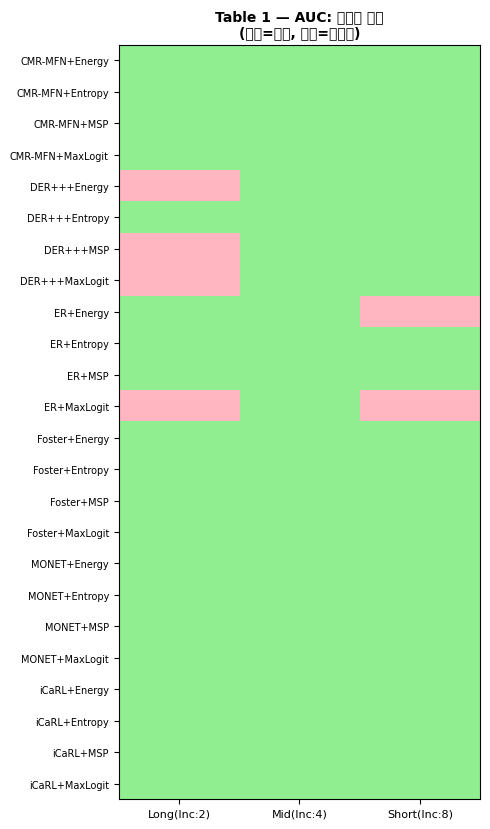

  저장: results/figures/significance_heatmap_AUC.png


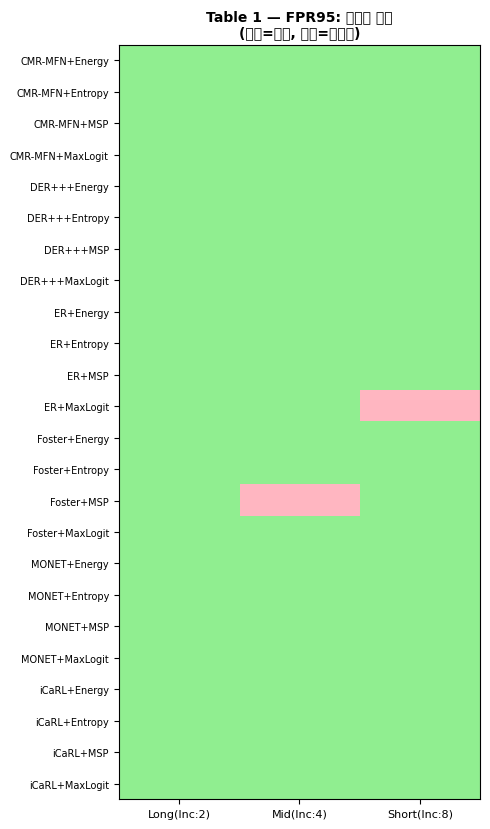

  저장: results/figures/significance_heatmap_FPR95.png


In [12]:
# ============================================================
# 유의미한 차이 비율 heat map (Table 1)
# ============================================================

if len(df_table1) > 0:
    for metric in ['AUC', 'FPR95']:
        sub = df_table1[df_table1['Metric'] == metric]
        pivot = sub.pivot_table(
            index=['CL_Method','Scoring'],
            columns='Increment',
            values='significant',
            aggfunc='first'
        ).astype(float)

        if len(pivot) == 0:
            continue

        fig, ax = plt.subplots(figsize=(5, max(4, len(pivot)*0.35)))
        import matplotlib.colors as mcolors
        cmap = mcolors.ListedColormap(['#FFB6C1', '#90EE90'])
        im = ax.imshow(pivot.values, cmap=cmap, aspect='auto', vmin=0, vmax=1)
        ax.set_xticks(range(len(pivot.columns)))
        ax.set_xticklabels([INC_NAMES[c] for c in pivot.columns], fontsize=8)
        ax.set_yticks(range(len(pivot.index)))
        ax.set_yticklabels([f"{a}+{b}" for a,b in pivot.index], fontsize=7)
        ax.set_title(f'Table 1 — {metric}: 유의성 여부\n(초록=유의, 분홍=비유의)',
                     fontsize=10, fontweight='bold')
        plt.tight_layout()
        fname = f'results/figures/significance_heatmap_{metric}.png'
        plt.savefig(fname, dpi=150, bbox_inches='tight')
        plt.show()
        print(f'  저장: {fname}')

## Cell 10. Excel 저장

In [13]:
# ============================================================
# results/paired_ttest_results.xlsx 에 저장
# ============================================================

OUTPUT_PATH = 'results/paired_ttest_results.xlsx'

with pd.ExcelWriter(OUTPUT_PATH, engine='openpyxl') as writer:

    # 시트 1: Table1 검정 결과 전체
    if len(df_table1) > 0:
        df_table1.to_excel(writer, sheet_name='Table1_Unknown', index=False)

    # 시트 2: Table2 검정 결과 전체
    if len(df_table2) > 0:
        df_table2.to_excel(writer, sheet_name='Table2_Known', index=False)

    # 시트 3: Table1 per-seed raw values
    if len(df_seed_t1) > 0:
        df_seed_t1.to_excel(writer, sheet_name='Seed_Values_AUC_FPR95', index=False)

    # 시트 4: Table2 per-seed raw values
    if len(df_seed_t2) > 0:
        df_seed_t2.to_excel(writer, sheet_name='Seed_Values_ACC_FGT', index=False)

    # 시트 5: Table1 Symbol Summary (논문 형식)
    if 'df_sym1' in dir() and len(df_sym1) > 0:
        df_sym1.to_excel(writer, sheet_name='Symbol_Summary_Table1', index=False)

    # 시트 6: Table2 Symbol Summary (논문 형식)
    if 'df_sym2' in dir() and len(df_sym2) > 0:
        df_sym2.to_excel(writer, sheet_name='Symbol_Summary_Table2', index=False)

    # 시트 7: 검정 설정 메타정보
    pd.DataFrame([
        {'항목': 'MAND(Ours) sweep ID', '값': SWEEP_IDS.get('MAND','')},
        {'항목': 'Baseline sweep IDs',  '값': str({k:v for k,v in SWEEP_IDS.items() if k!='MAND'})},
        {'항목': '유의수준 α',           '값': str(ALPHA)},
        {'항목': '정규성 검정',          '값': 'Shapiro-Wilk (차이값)'},
        {'항목': '정규분포 시 검정',     '값': 'Paired t-test (양측)'},
        {'항목': '비정규 시 검정',       '값': 'Wilcoxon signed-rank (양측)'},
        {'항목': 'Seeds',               '값': str(SEEDS)},
        {'항목': 'Increments',          '값': str(INCREMENTS)},
        {'항목': '▼ 의미',              '값': 'comp가 Ours보다 통계적으로 나쁨'},
        {'항목': '△ 의미',              '값': 'comp가 Ours보다 통계적으로 좋음'},
    ]).to_excel(writer, sheet_name='Meta_Config', index=False)

print(f'✅ Excel 저장 완료: {OUTPUT_PATH}')

✅ Excel 저장 완료: results/paired_ttest_results.xlsx


## Cell 11. 최종 요약

In [14]:
# ============================================================
# 전체 통계 요약
# ============================================================

print('=' * 70)
print('🎯 통계 검정 최종 요약')
print('=' * 70)

for label, df in [('Table 1 (AUC+FPR95)', df_table1),
                  ('Table 2 (ACC+FGT)',    df_table2)]:
    if len(df) == 0:
        print(f'\n{label}: 데이터 없음')
        continue
    total     = len(df)
    sig       = int(df['significant'].sum())
    ours_wins = int(((df['significant']) & (df['symbol']=='▼')).sum())
    comp_wins = int(((df['significant']) & (df['symbol']=='△')).sum())
    t_cnt     = int((df['test_used']=='paired_ttest').sum())
    w_cnt     = int((df['test_used']=='wilcoxon').sum())
    print(f'\n{label}')
    print(f'  전체 비교: {total}건')
    print(f'  유의한 차이: {sig}건 ({sig/total*100:.0f}%)')
    print(f'    ▼ Ours 우수 (comp 표에 ▼): {ours_wins}건')
    print(f'    △ Comp 우수 (comp 표에 △): {comp_wins}건')
    print(f'  사용된 검정: Paired t-test {t_cnt}건 / Wilcoxon {w_cnt}건')

print(f'\n📁 결과 저장: {OUTPUT_PATH}')

🎯 통계 검정 최종 요약

Table 1 (AUC+FPR95)
  전체 비교: 144건
  유의한 차이: 136건 (94%)
    ▼ Ours 우수 (comp 표에 ▼): 136건
    △ Comp 우수 (comp 표에 △): 0건
  사용된 검정: Paired t-test 140건 / Wilcoxon 4건

Table 2 (ACC+FGT)
  전체 비교: 36건
  유의한 차이: 27건 (75%)
    ▼ Ours 우수 (comp 표에 ▼): 27건
    △ Comp 우수 (comp 표에 △): 0건
  사용된 검정: Paired t-test 35건 / Wilcoxon 1건

📁 결과 저장: results/paired_ttest_results.xlsx
